In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
plt.rcParams['font.size'] = 16

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0430_dps_test.fits')

In [3]:
stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
stellar_df.head()

,TARGETID,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056154,DEV,4.000000,1.577094,145.330002,44.629128
1,39627739380056197,REX,1.000000,0.969577,78.970001,0.000000
2,39627739380056420,SER,0.722487,2.256895,2.770000,79.009950
3,39627739380056564,REX,1.000000,1.275339,59.770000,0.000000
4,39627739380056768,EXP,1.000000,3.253861,72.139999,78.399880


In [4]:
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274399,-78.119492,48.701080,29.865618,...,256,512,0.227097,-0.661874,1,REX,1.000000,1.275339,59.770000,0.000000
1,39627739380057763,177.068542,-1.882260,0.242461,10.436480,-0.020428,7.801134,-78.896767,67.312065,136.300995,...,4,5,1.327266,1.113020,2,SER,5.779601,1.626138,32.099998,41.719790
2,39627739380058101,177.082611,-1.934162,0.155560,10.225355,0.697434,7.893916,-34.556438,52.043594,83.238007,...,1,2,0.308400,0.344668,1,SER,0.500000,1.606306,10.700000,71.624450
3,39627739380059797,177.158051,-1.894803,0.191538,10.211300,0.980484,5.134137,-12.588565,24.090601,86.820892,...,1,2,1.036606,1.234036,5,REX,1.000000,0.712561,0.000000,0.000000
4,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,78.897018,-91.391823,57.324131,58.142452,...,256,512,-0.173369,-1.161603,2,SER,2.648419,1.265829,124.010002,47.433067


In [5]:
dps_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [6]:
print(len(dps_df))

25767


In [7]:
model_1comp_dps = model_1comp_dps[dps_df.index]
left_2comp_dps = left_2comp_dps[dps_df.index]
right_2comp_dps = right_2comp_dps[dps_df.index]

In [8]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


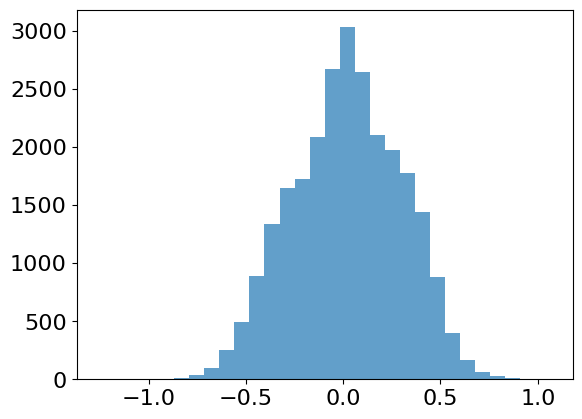

In [9]:
plt.hist(np.log10(dps_df['width_ratio']), bins=30, alpha=0.7, color='C0')
plt.show()

In [10]:
print(len(dps_df[np.log10(dps_df['width_ratio'])<0]))
print(len(dps_df[np.log10(dps_df['width_ratio'])>0]))

11955
13812


In [11]:
dps_df['flux_ratio'] = 0
for i in range(len(dps_df)):
    lam = desi_wavelength/(1+dps_df['Z'][i])
    left_shift = dps_df['DV_L'][i] / c * Halpha_rest[0]
    right_shift = dps_df['DV_R'][i] / c * Halpha_rest[0]

    left_flux = np.max(left_2comp_dps[i][(lam>(Halpha_rest[0]+left_shift-2)) & (lam<(Halpha_rest[0]+left_shift+2))])
    right_flux = np.max(right_2comp_dps[i][(lam>(Halpha_rest[0]+right_shift-2)) & (lam<(Halpha_rest[0]+right_shift+2))])

    if ((right_flux < 1) and (left_flux < 1)) or (dps_df['Halpha_DP'].iloc[i] is False):
        dps_df['flux_ratio'].iloc[i] = np.nan
    else:
        dps_df['flux_ratio'].iloc[i] = left_flux / right_flux


# dps_df['flux_ratio'] = 0
# for i in range(len(dps_df)):
#     lam = desi_wavelength/(1+dps_df['Z'][i])
#     left_shift = dps_df['DV_L'][i] / c * OIII_rest[1]
#     right_shift = dps_df['dv_r'][i] / c * OIII_rest[1]

#     left_flux = np.max(left_2comp_dps[i][(lam>(OIII_rest[1]+left_shift-2)) & (lam<(OIII_rest[1]+left_shift+2))])
#     right_flux = np.max(right_2comp_dps[i][(lam>(OIII_rest[1]+right_shift-2)) & (lam<(OIII_rest[1]+right_shift+2))])

#     if ((right_flux < 1) and (left_flux < 1)) or (dps_df['OIII5007_dp'].iloc[i] is False):
#         dps_df['flux_ratio'].iloc[i] = np.nan
#     else:
#         dps_df['flux_ratio'].iloc[i] = left_flux / right_flux



/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_10828/1256411409.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dps_df['flux_ratio'].iloc[i] = left_flux / right_flux
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel

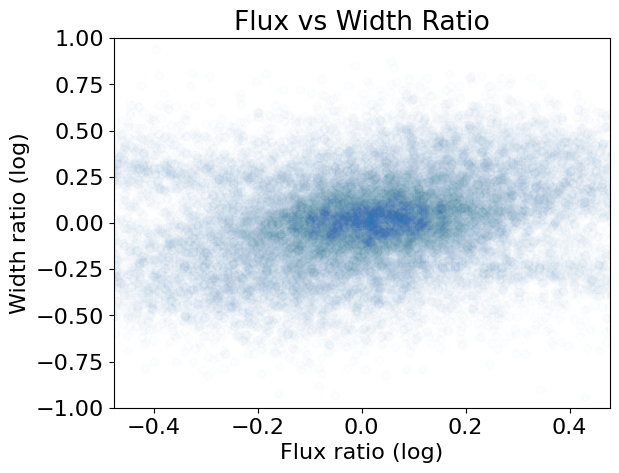

In [12]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(dps_df['width_ratio'])), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(dps_df['width_ratio'])), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.ylim(bottom=np.log10(1/10), top=np.log10(10))
plt.title('Flux vs Width Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/flux_width_ratio.png')
plt.show()

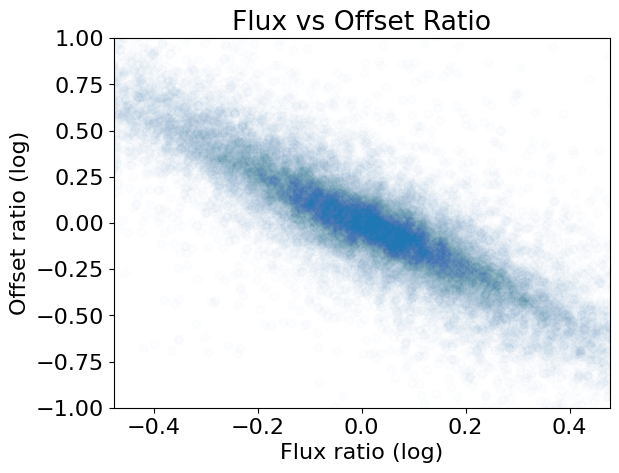

In [13]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(-dps_df['DV_L']/(dps_df['dv_r']))), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(-dps_df['DV_L']/(dps_df['DV_R']))), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.ylim(bottom=-1, top=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.title('Flux vs Offset Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Offset ratio (log)')
plt.savefig('./figures/Feb6/flux_offset_ratio.png')
plt.show()

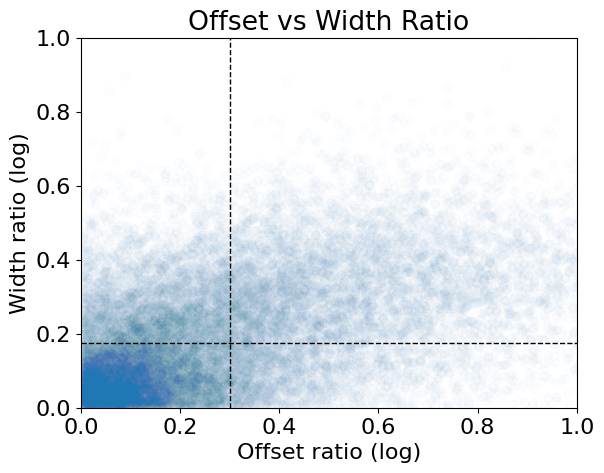

In [14]:
plt.scatter(np.abs(np.log10(-dps_df['DV_L']/(dps_df['DV_R']))), np.abs(np.log10(dps_df['width_ratio'])), alpha=0.01)
# plt.scatter((np.log10(-dps_df['DV_L']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.axvline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=0, right=1)
plt.ylim(bottom=0, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/offset_width_ratio_abs.png')
plt.show()

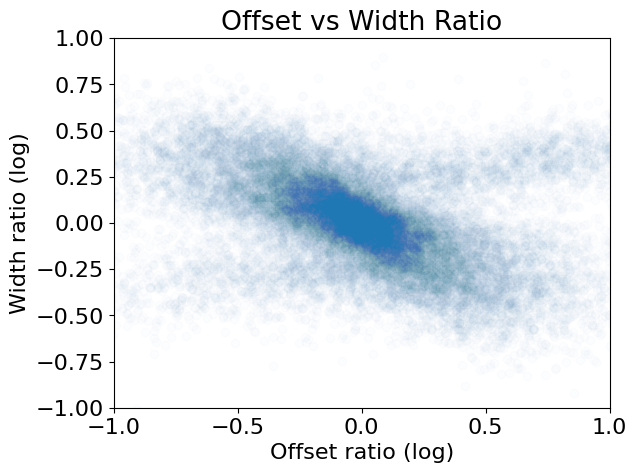

In [15]:
plt.scatter((np.log10(-dps_df['DV_L']/(dps_df['DV_R']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.xlim(left=-1, right=1)
plt.ylim(bottom=-1, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.show()

In [16]:
# print(len(dps_df[np.log10(-dps_df['DV_L']/(dps_df['dv_r']))<0]))
# print(len(dps_df[np.log10(-dps_df['DV_L']/(dps_df['dv_r']))>0]))

In [17]:
def extract_symmetry(df, flux=None, width=None, offset=None):
    combine_crit = np.ones(len(df), dtype=bool)
    
    if flux is True:
        # flux_crit = np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
        combine_crit &= np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
    elif flux is False:
        combine_crit &=  np.abs(np.log10(df['flux_ratio']))>=np.log10(1.3)
    elif flux is None:
        pass

    if width is True:
        combine_crit &= np.abs(np.log10(df['width_ratio']))<np.log10(1.5)
    elif width is False:
        combine_crit &= np.abs(np.log10(df['width_ratio']))>=np.log10(1.5)
    elif width is None:
        pass

    if offset is True:
        combine_crit &= np.abs(np.log10(-df['DV_L']/(df['DV_R'])))<np.log10(2)
    elif offset is False:
        combine_crit &= np.abs(np.log10(-df['DV_L']/(df['DV_R'])))>=np.log10(2)
    elif offset is None:
        pass

    return df[combine_crit]


In [18]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [19]:
dps_df['BPT_class_str'] = dps_df['BPT_2COMP'].map(classification_map)

In [20]:
sWsO = extract_symmetry(dps_df, flux=None, width=True, offset=True)
sWsO.head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274399,-78.119492,48.701080,29.865618,...,1,REX,1.000000,1.275339,59.770000,0.000000,131.393890,0.726522,0.975135,unclassified
4,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,78.897018,-91.391823,57.324131,58.142452,...,2,SER,2.648419,1.265829,124.010002,47.433067,170.288849,1.011303,0.853461,unclassified
5,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.714844,-73.869621,38.259602,50.303757,...,7,SER,1.779606,0.794439,100.040001,50.672260,161.584473,1.190214,1.091792,double SF
7,39627739384253125,177.367218,-1.890628,0.082792,9.603887,0.054528,33.326653,-35.945473,38.321335,31.474480,...,9,SER,1.508034,1.499528,62.330002,69.412030,69.272125,0.903709,1.053874,double SF
8,39627739384253866,177.401154,-1.923410,0.322626,10.556721,1.160900,75.359352,-83.432549,62.639046,50.840076,...,2,SER,1.109368,1.686460,200.000000,41.732790,158.791901,0.845168,0.891371,unclassified


In [21]:
print(sWsO['BPT_class_str'].value_counts())

BPT_class_str
double SF       4494
unclassified    2916
SF+COMP          779
double COMP      372
SF+AGN           128
COMP+AGN          88
double AGN        56
COMP+LINER        12
AGN+LINER         12
SF+LINER           3
Name: count, dtype: int64


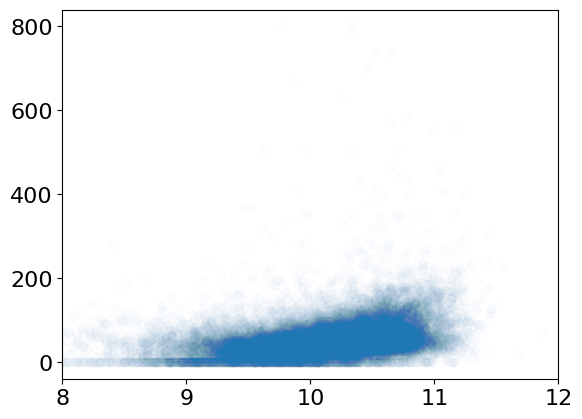

In [22]:
plt.scatter(dps_df['LOGM'], (dps_df['SIGMA_R']), alpha=0.01)
plt.xlim(left=8, right=12)
plt.show()

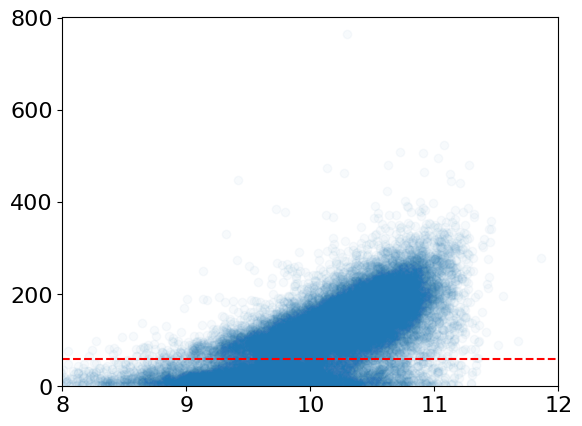

In [23]:
plt.scatter(dps_df['LOGM'], (dps_df['delta_dv']), alpha=0.03)
plt.axhline(60, color='r', linestyle='--')
plt.xlim(left=8, right=12)
plt.ylim(bottom=0)
plt.show()

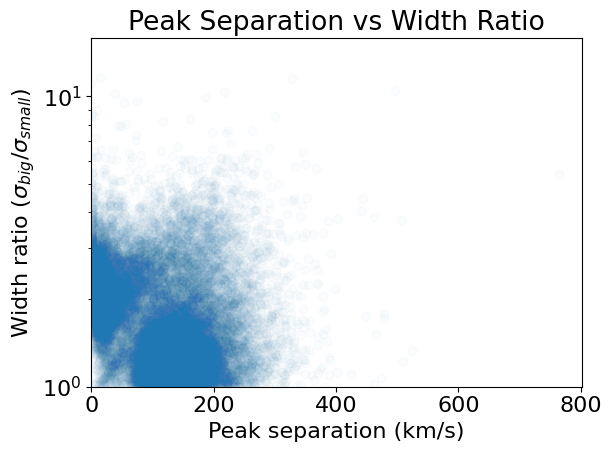

In [24]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], 10**np.abs(np.log10(dps_df['width_ratio'])), alpha=0.02)
# plt.plot(x, y, color='r', linestyle='--')
# plt.axvline(60, color='r', linestyle='--')
# plt.axhline(0.1, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
plt.title('Peak Separation vs Width Ratio')
plt.tight_layout()
plt.savefig('./figures/progress_apr/peak_sep_width_ratio.png')
plt.show()

In [25]:

# robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(~dps_df['incl'].isnull())&(dps_df['dp_count']>1)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())&(~robust_dps['flux_ratio'].isnull())]
robust_dps.sort_values(['width_ratio'], ascending=True).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
13617,39627782338119011,217.557510,-0.172370,0.103793,9.859334,0.079349,9.675587,-0.226691,666.670776,16.894445,...,1,REX,1.0,0.564181,15.630000,0.000000,9.902278,0.055673,5.696422,SF+COMP
19183,39627800507843254,220.529312,0.442727,0.179778,10.918049,-10.475061,66.623528,-261.924591,352.986786,0.001000,...,1,SER,6.0,1.156855,186.690002,28.587997,328.548126,0.087393,0.353004,SF+AGN
14558,39627787975265281,193.637573,0.004602,0.372979,10.631804,1.618834,33.986889,-4.169449,571.181274,49.483376,...,1,REX,1.0,0.550339,119.900002,0.000000,38.156338,0.098258,7.204100,SF+COMP
25631,39627824591541267,216.206161,1.398241,0.107625,9.899554,0.002022,73.040344,-1.157624,414.080109,27.460520,...,1,SER,6.0,0.386797,95.320000,10.429887,74.197968,0.103322,4.190063,SF+COMP
10767,39627775912443947,194.500443,-0.463483,0.245176,9.776242,0.941007,51.453232,-2.040342,800.000000,79.283615,...,1,REX,1.0,0.297201,101.779999,0.000000,53.493572,0.105602,5.359616,SF+COMP


In [26]:
print(len(robust_dps))

15470


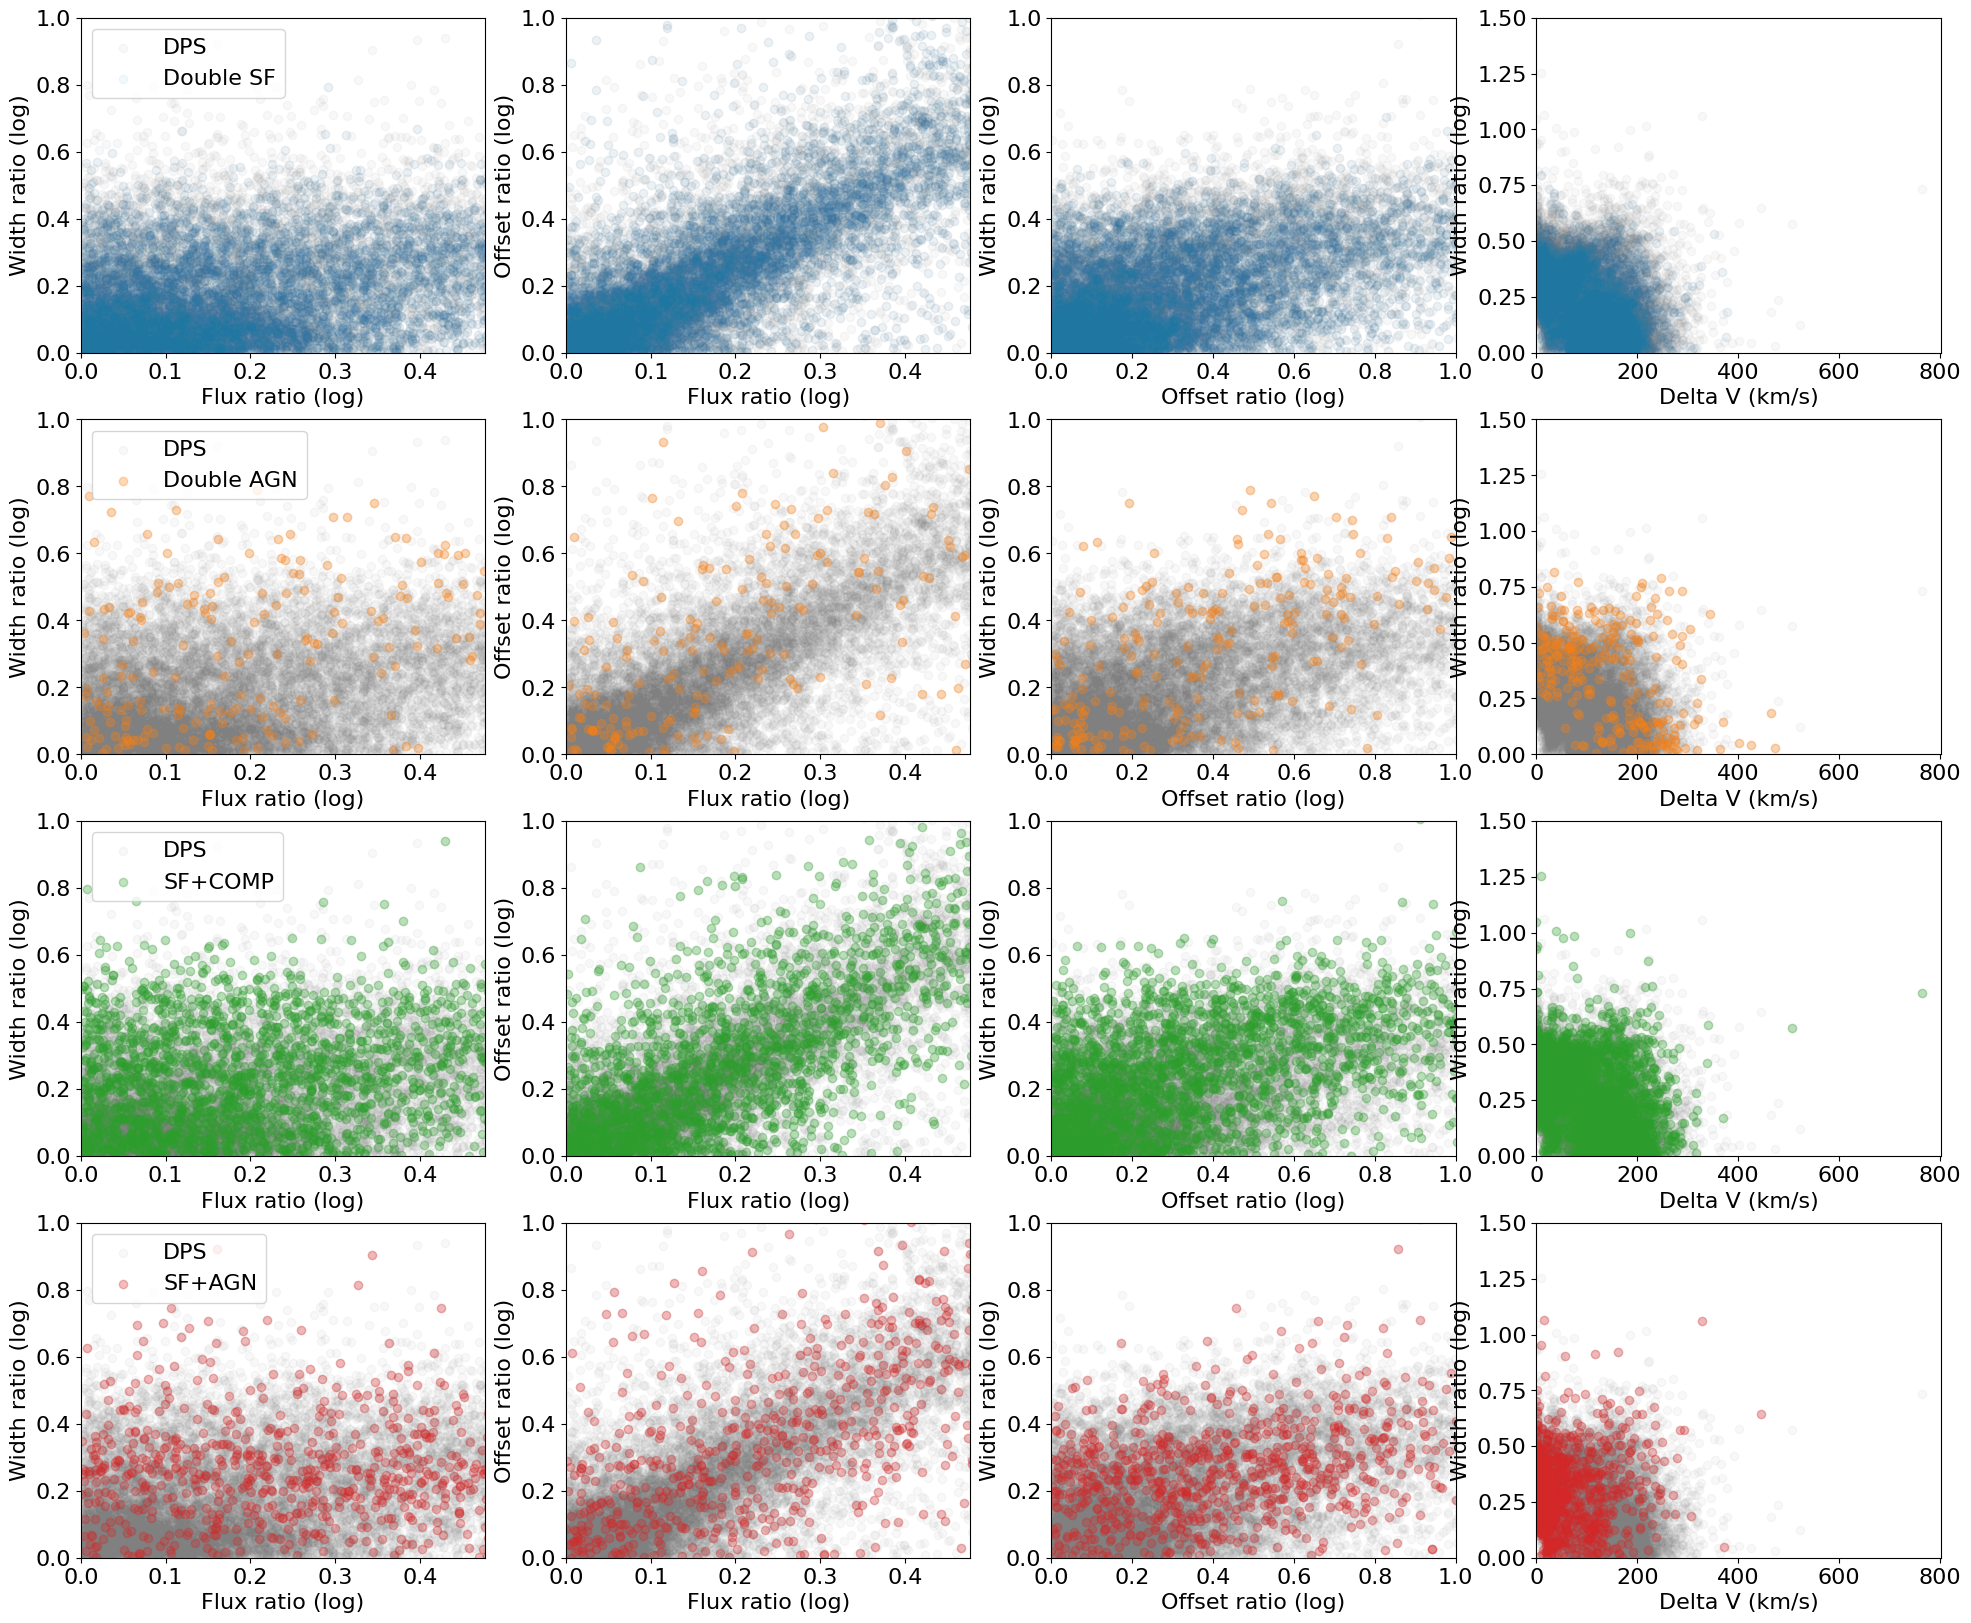

In [27]:

dSF = robust_dps[robust_dps['BPT_class_str']=='double SF'].copy()
dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN'].copy()
SF_COMP = robust_dps[robust_dps['BPT_class_str']=='SF+COMP'].copy()
SF_AGN = robust_dps[robust_dps['BPT_class_str']=='SF+AGN'].copy()

fig, axes = plt.subplots(4, 4, figsize=(24, 20))

labels = ['Double SF', 'Double AGN', 'SF+COMP', 'SF+AGN']
colors = ['C0', 'C1', 'C2', 'C3']
for i, subset in enumerate([dSF, dAGN, SF_COMP, SF_AGN]):
    ax = axes[i]
    ax[0].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(robust_dps['width_ratio'])), alpha=.05, color='gray', label='DPS')
    ax[0].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(subset['width_ratio'])), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[0].set_xlim(left=0, right=np.log10(3))
    ax[0].set_ylim(bottom=0, top=np.log10(10))
    ax[0].set_xlabel('Flux ratio (log)')
    ax[0].set_ylabel('Width ratio (log)')
    ax[0].legend()


    ax[1].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(-robust_dps['DV_L']/(robust_dps['DV_R']))), alpha=.05, color='gray', label='DPS')
    ax[1].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(-subset['DV_L']/(subset['DV_R']))), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[1].set_ylim(bottom=0, top=1)
    ax[1].set_xlim(left=0, right=np.log10(3))
    ax[1].set_xlabel('Flux ratio (log)')
    ax[1].set_ylabel('Offset ratio (log)')

    ax[2].scatter(np.abs(np.log10(-robust_dps['DV_L']/(robust_dps['DV_R']))), np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[2].scatter(np.abs(np.log10(-subset['DV_L']/(subset['DV_R']))), np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[2].set_xlim(left=0, right=1)
    ax[2].set_ylim(bottom=0, top=1)
    ax[2].set_xlabel('Offset ratio (log)')
    ax[2].set_ylabel('Width ratio (log)')
    
    ax[3].scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[3].scatter(subset['delta_dv'], np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[3].set_xlim(left=0)
    ax[3].set_ylim(bottom=0, top=1.5)
    ax[3].set_xlabel('Delta V (km/s)')
    ax[3].set_ylabel('Width ratio (log)')


plt.show()




In [28]:
# merger_cand = robust_dps[((robust_dps['width_ratio']<1/3)|(robust_dps['width_ratio']>3))].copy()
# merger_cand_b = merger_cand[(merger_cand['width_ratio']>3)&(merger_cand['sigma_l']<250)&(merger_cand['sigma_r']>1)].copy()
# merger_cand_r = merger_cand[(merger_cand['width_ratio']<1/3)&(merger_cand['sigma_r']<250)&(merger_cand['sigma_l']>1)].copy()
# merger_cand = pd.concat([merger_cand_b, merger_cand_r])
# merger_cand.sort_values(['width_ratio'], ascending=False).head(5)

In [29]:
# for i, id in enumerate(merger_cand.sort_values(['width_ratio'], ascending=False).head(10)['TARGETID'].to_list()):
#     df = merger_cand[merger_cand['TARGETID'] == id]
#     print(df['BPT_class_str'])
#     print(image_link(df['RA'].iloc[0], df['DEC'].iloc[0], plot=True, save_image=True, fname=f"./images/{id}_image.jpg"))

In [30]:
# plt.scatter(robust_dps['LOGM'], np.log10(robust_dps['sigma_l']/robust_dps['VD_SL']), alpha=0.05)
# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.xlim(left=8, right=12)
# plt.show()

In [31]:
# from scipy.stats import binned_statistic

# # Bin the data by 'LOGM'
# bin_means, bin_edges, binnumber = binned_statistic(robust_dps['LOGM'],
#                                                    robust_dps['sigma_l'] - robust_dps['VD_SL'],
#                                                    statistic='mean',
#                                                    bins=5, range=(9, 11.5))
# bin_stds, _, _ = binned_statistic(robust_dps['LOGM'],
#                                   robust_dps['sigma_l'] - robust_dps['VD_SL'],
#                                   statistic='std',
#                                   bins=5, range=(9, 11.5))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# # Create the plot
# # plt.figure(figsize=(8, 6))
# # Plot the original scatter data
# plt.scatter(robust_dps['LOGM'], robust_dps['sigma_l'] - robust_dps['VD_SL'], alpha=0.05, label='All data')
# # Plot the binned means with error bars
# plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', color='r', label='Binned Mean +/- Std Dev')

# # Set plot labels and limits
# plt.xlabel('LOGM')
# plt.ylabel('sigma_l - VD_SL')
# plt.xlim(left=8, right=12)
# plt.legend()
# plt.show()

In [32]:
robust_dps.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [33]:
# plt.scatter(robust_dps['Z'], robust_dps['LOGM'], alpha=0.05)
# plt.show()

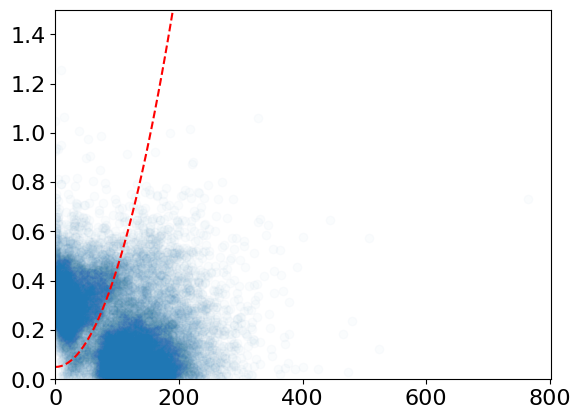

In [34]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.02)
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.show()

In [35]:
cake_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 < np.abs(np.log10(robust_dps['width_ratio']))].copy()
horn_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 > np.abs(np.log10(robust_dps['width_ratio']))].copy()

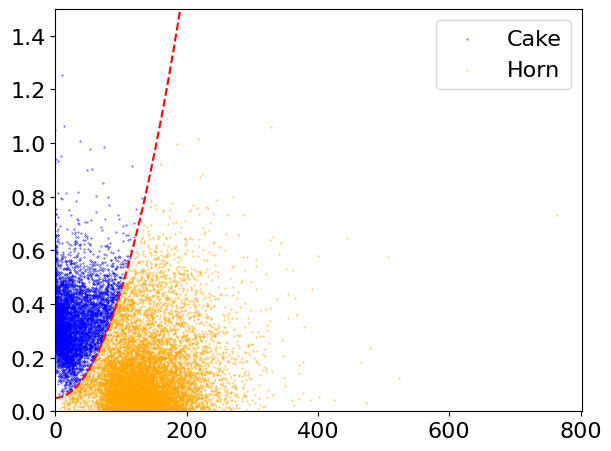

In [36]:
plt.scatter(cake_dps['delta_dv'], np.abs(np.log10(cake_dps['width_ratio'])), alpha=1, color='blue', label='Cake', s=0.1)
plt.scatter(horn_dps['delta_dv'], np.abs(np.log10(horn_dps['width_ratio'])), alpha=1, color='orange', label='Horn', s=0.1)
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/cake_horn.png')
plt.show()

In [37]:
cake_dps.sort_values('delta_dv').head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
393,39627739723993940,197.722153,-1.979395,0.150217,9.489893,0.272094,2.208414e-37,-2.076046e-37,0.001002,54.634430,...,1,REX,1.000000,0.468103,54.910000,0.000000,4.284460e-37,1.989633,2.521024,double SF
9929,39627770329830438,221.976761,-0.780556,0.312779,10.717134,1.148593,8.363112e-37,-3.409054e-39,213.478516,56.607418,...,1,SER,2.530850,1.225947,57.669998,49.454430,8.397202e-37,0.293000,7.148303,SF+COMP
15013,39627788168200467,205.009796,0.091309,0.220165,10.292040,1.308811,1.740425e-36,-3.498088e-37,142.715790,32.177006,...,2,SER,5.475340,2.650563,160.580002,62.049538,2.090233e-36,0.301415,5.990709,SF+COMP
13031,39627782073876995,201.769135,-0.270687,0.186199,10.263815,0.814279,5.431044e-36,-5.867677e-37,97.663902,17.943491,...,1,REX,1.000000,1.358871,53.529999,0.000000,6.017811e-36,0.348079,9.207673,double SF
22421,39627812394502377,209.115112,0.898332,0.260556,10.466062,1.816271,6.281956e-36,-1.584427e-38,85.782341,208.420334,...,6,SER,5.208826,0.932044,139.110001,34.257706,6.297801e-36,2.323962,0.287552,double AGN
2520,39627746137085542,219.963318,-1.852669,0.133779,10.061270,0.584262,6.636991e-36,-1.422041e-35,120.480103,31.491369,...,2,SER,1.939874,1.562597,27.410000,37.201973,2.085740e-35,0.361273,5.849925,SF+COMP
6609,39627763673467468,185.109070,-1.104846,0.154547,9.921696,0.108289,4.198963e-35,-3.594462e-36,68.402016,7.976062,...,3,REX,1.000000,0.943817,28.000000,0.000000,4.558409e-35,0.432996,3.712437,SF+COMP
10319,39627775719511177,183.231995,-0.599808,0.074875,10.164713,0.679692,1.024685e-34,-3.856045e-38,51.433659,152.509262,...,2,EXP,1.000000,3.859227,87.750000,77.544110,1.025070e-34,2.534493,0.264190,SF+COMP
1711,39627745780568021,198.692856,-1.726080,0.177899,9.397820,0.343936,3.388509e-34,-2.491635e-36,66.476402,13.040327,...,1,SER,0.706492,1.619631,152.130005,44.214924,3.413426e-34,0.458670,1.597845,double SF
24158,39627818375579835,205.602066,1.283070,0.220856,9.931198,1.422858,6.983822e-35,-6.434085e-34,193.944168,40.065678,...,2,SER,4.989647,2.337681,28.170000,58.323100,7.132467e-34,0.254830,4.298906,SF+COMP


In [56]:
horn_dps[horn_dps['delta_dv']>250].sort_values('dp_count', ascending=False).head(40)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
13623,39627782338122510,217.722092,-0.154867,0.123403,10.203592,1.076012,146.779495,-118.620895,104.676308,119.851440,...,10,DEV,4.000000,0.763459,168.740005,58.123734,265.400391,1.132955,1.098688,double AGN
13749,39627782384257143,220.318146,-0.128447,0.139451,10.531192,1.353500,142.083435,-141.701172,91.108421,127.096062,...,10,SER,4.285465,4.140452,126.870003,45.059020,283.784607,1.357117,0.763560,double AGN
11606,39627776243797533,214.391190,-0.389728,0.271251,10.058723,1.773231,133.410950,-155.083786,93.043839,65.360718,...,10,SER,1.653497,0.741995,168.740005,61.463660,288.494751,0.733201,1.072911,double COMP
23497,39627818081978671,188.105759,1.197320,0.208237,9.769729,1.284289,130.004166,-132.522568,87.370750,84.579994,...,10,SER,1.873374,0.892516,121.480003,65.942150,262.526733,0.971525,0.986580,double SF
22267,39627812327392032,205.030869,1.124990,0.356419,10.530293,1.155232,118.829292,-151.475281,84.020233,81.609581,...,10,DEV,4.000000,0.918714,104.250000,50.162876,270.304565,0.974018,0.754045,double AGN
23356,39627818027453033,184.901169,1.267236,0.150444,10.222018,1.804142,175.333221,-89.920052,93.762909,147.726852,...,10,SER,2.304330,0.778616,172.479996,48.934480,265.253265,1.526360,1.982636,COMP+AGN
14679,39627788025595216,196.555328,0.094931,0.348952,10.287323,1.940752,137.206787,-120.768089,107.362686,96.334900,...,10,SER,2.691531,1.484144,187.759995,67.857376,257.974884,0.903758,1.356912,double AGN
16751,39627794161862207,202.321075,0.249177,0.376161,10.182315,2.083117,143.937180,-141.585052,90.525223,72.650429,...,9,SER,0.547259,1.004779,134.300003,45.063700,285.522217,0.819916,1.614885,SF+COMP
15637,39627788428252634,220.714249,0.049977,0.285629,10.738217,0.415376,156.327194,-143.180237,55.034592,119.383194,...,9,SER,3.391138,0.858083,279.269989,38.422630,299.507446,1.981306,0.551794,double SF
14264,39627787832658574,185.129288,0.074819,0.207782,10.327528,-4.719077,120.167007,-130.212296,82.165291,62.075432,...,9,DEV,4.000000,0.464466,99.529999,73.100555,250.379303,0.788672,1.131305,double AGN


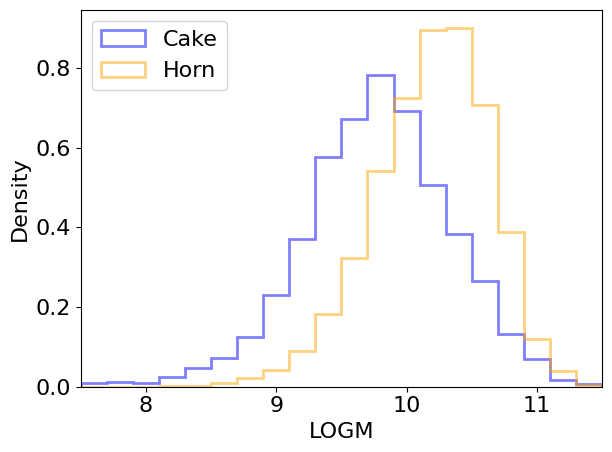

In [39]:
plt.hist(cake_dps['LOGM'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(7.5, 11.5))
plt.hist(horn_dps['LOGM'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(7.5, 11.5))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=7.5, right=11.5)
# plt.savefig('./figures/Feb25/cake_horn_logm.png')
plt.show()

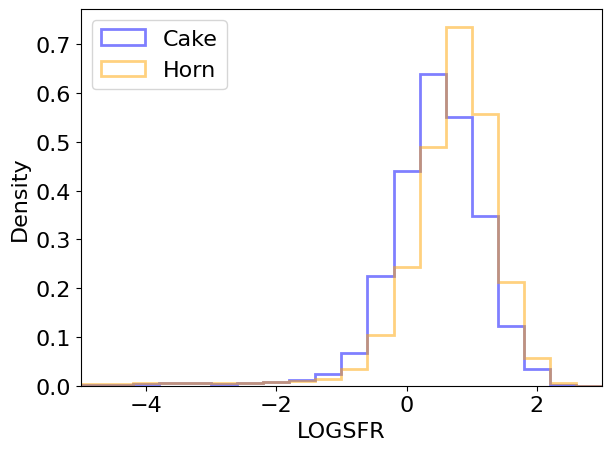

In [40]:
plt.hist(cake_dps['LOGSFR'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(-5, 3))
plt.hist(horn_dps['LOGSFR'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(-5, 3))
plt.xlabel('LOGSFR')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=-5, right=3)
plt.tight_layout()
# plt.savefig('./figures/Feb25/cake_horn_logsfr.png')
plt.show()

In [41]:
print(cake_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(cake_dps))

BPT_class_str
double SF         56.031485
SF+COMP           22.020868
SF+AGN            13.088047
COMP+AGN           2.654219
double COMP        2.526085
double AGN         1.848801
SF+LINER           0.878638
AGN+LINER          0.311184
COMP+LINER         0.311184
AGN+uncertain      0.164745
COMP+uncertain     0.128135
SF+uncertain       0.036610
Name: proportion, dtype: float64
5463


In [42]:
print(horn_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(horn_dps))

BPT_class_str
double SF         67.043070
SF+COMP           16.868192
double COMP        7.164985
SF+AGN             3.617468
COMP+AGN           2.558209
double AGN         1.648846
COMP+LINER         0.439692
AGN+LINER          0.319776
SF+LINER           0.249825
COMP+uncertain     0.049965
SF+uncertain       0.029979
AGN+uncertain      0.009993
Name: proportion, dtype: float64
10007
